In [3]:
import pandas as pd

# CSV dosyamızı okutup 'df' (dataframe) adında bir tabloya atıyoruz
df = pd.read_csv("credit_risk_dataset.csv")

# Tablonun ilk 5 satırını ekrana yazdırıp "veri sağlam geldi mi?" diye kontrol ediyoruz (SQL'deki SELECT TOP 5 mantığı)
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
# Veri setinin genel şemasını ve tiplerini görüyoruz (Kaç satır, string mi integer mı?)
df.info()

print("\n" + "="*40 + "\n")

# Hangi sütunda kaç tane eksik (boş) satır var onu saydırıyoruz
print("EKSİK VERİ SAYILARI:")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


EKSİK VERİ SAYILARI:
person_age             

In [5]:
# person_emp_length sütunundaki boşlukları o sütunun medyan değeri ile dolduruyoruz
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())

# loan_int_rate sütunundaki boşlukları da aynı şekilde medyan ile dolduruyoruz
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())

# İşlem başarılı mı diye tekrar boşlukları saydırıyoruz (Hepsini 0 görmemiz lazım)
print("TEMİZLİK SONRASI EKSİK VERİLER:")
print(df.isnull().sum())

TEMİZLİK SONRASI EKSİK VERİLER:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


In [6]:
# Pandas'ın get_dummies fonksiyonu ile tüm metin sütunlarını otomatik bulup 0-1 matrislerine çeviriyoruz.
# drop_first=True diyerek Kukla Değişken Tuzağından (Dummy Variable Trap) kaçınıyoruz.
# dtype=int diyerek True/False yerine net olarak 1 ve 0 yazdırıyoruz.

df = pd.get_dummies(df, drop_first=True, dtype=int)

# Verimizin yeni haline ve kolon sayısına bakalım (Kolon sayısı artmış olmalı!)
print(df.info())

# Tablonun son haline bir göz atalım
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   person_age                   32581 non-null  int64  
 1   person_income                32581 non-null  int64  
 2   person_emp_length            32581 non-null  float64
 3   loan_amnt                    32581 non-null  int64  
 4   loan_int_rate                32581 non-null  float64
 5   loan_status                  32581 non-null  int64  
 6   loan_percent_income          32581 non-null  float64
 7   cb_person_cred_hist_length   32581 non-null  int64  
 8   person_home_ownership_OTHER  32581 non-null  int64  
 9   person_home_ownership_OWN    32581 non-null  int64  
 10  person_home_ownership_RENT   32581 non-null  int64  
 11  loan_intent_EDUCATION        32581 non-null  int64  
 12  loan_intent_HOMEIMPROVEMENT  32581 non-null  int64  
 13  loan_intent_MEDICAL        

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,123.0,35000,16.02,1,0.59,3,0,0,...,0,1,0,0,0,1,0,0,0,1
1,21,9600,5.0,1000,11.14,0,0.10,2,0,1,...,0,0,0,1,0,0,0,0,0,0
2,25,9600,1.0,5500,12.87,1,0.57,3,0,0,...,1,0,0,0,1,0,0,0,0,0
3,23,65500,4.0,35000,15.23,1,0.53,2,0,0,...,1,0,0,0,1,0,0,0,0,0
4,24,54400,8.0,35000,14.27,1,0.55,4,0,0,...,1,0,0,0,1,0,0,0,0,1


In [7]:
# Sadece şüphelendiğimiz 3 sütunun (Yaş, Çalışma Süresi, Gelir) istatistiksel özetine bakalım.
# Virgülden sonra çok uzamasın diye formatlıyoruz.
pd.options.display.float_format = '{:.2f}'.format
print(df[['person_age', 'person_emp_length', 'person_income']].describe())

       person_age  person_emp_length  person_income
count    32581.00           32581.00       32581.00
mean        27.73               4.77       66074.85
std          6.35               4.09       61983.12
min         20.00               0.00        4000.00
25%         23.00               2.00       38500.00
50%         26.00               4.00       55000.00
75%         30.00               7.00       79200.00
max        144.00             123.00     6000000.00


In [8]:
# Başlangıçtaki satır sayımızı görelim
print(f"Temizlik öncesi satır sayısı: {len(df)}")

# Yaşı 100'den küçük olanları VE çalışma süresi 60 yıldan az olanları tutuyoruz. 
# (Pandas'ta 've' işlemi & işareti ile yapılır)
df = df[(df['person_age'] < 100) & (df['person_emp_length'] < 60)]

# Temizlik sonrası satır sayımızı görelim
print(f"Temizlik sonrası satır sayısı: {len(df)}")

# Kontrol için maksimum yaş ve çalışma süresine tekrar bakalım
print("\nYENİ MAKSİMUM DEĞERLER:")
print(f"Max Yaş: {df['person_age'].max()}")
print(f"Max Çalışma Süresi: {df['person_emp_length'].max()}")

Temizlik öncesi satır sayısı: 32581
Temizlik sonrası satır sayısı: 32574

YENİ MAKSİMUM DEĞERLER:
Max Yaş: 94
Max Çalışma Süresi: 41.0


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. X (Girdiler) ve y (Hedef Çıktı) Ayrımı
# Hedefimiz 'loan_status' (Krediyi öder mi? 0 veya 1). 
# X, bu sütun hariç her şeydir (SQL'deki SELECT * EXCEPT mantığı). y ise sadece bu sütundur.
X = df.drop('loan_status', axis=1)
y = df['loan_status']

# 2. Veriyi %80 Eğitim, %20 Test olacak şekilde bölüyoruz. 
# random_state=42 kısmı, her çalıştırdığımızda aynı %20'yi rastgele seçmesi içindir (standart bir best-practice).
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Ölçeklendirme (Scaling) İşlemi
scaler = StandardScaler()

# ÇOK KRİTİK: Scaler'ı SADECE Eğitim verisine bakarak (öğrenerek) ayarlıyoruz ve dönüştürüyoruz (fit_transform).
# Test verisini ise (kopya çekmesin, gelecekteki bir veri gibi davransın diye) SADECE dönüştürüyoruz (transform).
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Eğitim için ayrılan müşteri sayısı: {X_train_scaled.shape[0]}")
print(f"Test (Sınav) için ayrılan müşteri sayısı: {X_test_scaled.shape[0]}")
print(f"Her müşterinin sahip olduğu özellik (sütun) sayısı: {X_train_scaled.shape[1]}")

Eğitim için ayrılan müşteri sayısı: 26059
Test (Sınav) için ayrılan müşteri sayısı: 6515
Her müşterinin sahip olduğu özellik (sütun) sayısı: 22


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Modeli başlatıyoruz (Katmanları Lego gibi üst üste ekleyeceğimiz yapı)
model = Sequential()

# 1. GİZLİ KATMAN (Aynı zamanda Girdi Kapısını da tanımlar)
# 64 nöron koyuyoruz. input_shape=(22,) diyerek 22 sütunluk veriyi kabul edeceğini söylüyoruz.
model.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))

# Dropout: Her adımda nöronların %20'sini rastgele kapatarak ezberi boz (Regularization)
model.add(Dropout(0.2))

# 2. GİZLİ KATMAN
# Bilgiyi damıtmak için nöron sayısını 64'ten 32'ye düşürerek daralan bir yapı kuruyoruz.
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))

# ÇIKTI KATMANI (OUTPUT)
# Sadece 1 nöron ve Sigmoid aktivasyonu (Bize 0 ile 1 arası bir risk olasılığı verecek)
model.add(Dense(1, activation='sigmoid'))

# Modelin röntgenini (mimarisini ve parametre sayılarını) ekrana yazdır
model.summary()

c:\Users\eneso.DESKTOP-IVNDOU7\OneDrive\Masaüstü\Kredi-Risk-YPA\proje_ortami\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,585 (14.00 KB)

 Trainable params: 3,585 (14.00 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# 1. MODELİ DERLEME (Kullanım Kılavuzu Verme)
# optimizer='adam': Hatayı düşürmek için ağırlıkları güncelleyecek en popüler navigasyon algoritması.
# loss='binary_crossentropy': Sonuç 0 veya 1 olacağı için İkili Çapraz Entropi hata fonksiyonunu kullanıyoruz.
# metrics=['accuracy']: Biz insanlar için ekrana başarı yüzdesini (doğruluk) yazdır.
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 2. MODELİ EĞİTME (Matrisleri Çarpıştırma)
# epochs=50: Tüm veri setini (26 bin müşteriyi) ağa 50 kez baştan sona göster.
# batch_size=32: Müşterileri ağa 32'şerli gruplar halinde sok (RAM şişmesin diye).
# validation_split=0.2: Eğitim yaparken bir yandan da verinin %20'siyle kendini test et, ezberliyor musun görelim.
history = model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2)

Epoch 1/50
652/652 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8463 - loss: 0.3795 - val_accuracy: 0.8843 - val_loss: 0.3111
Epoch 2/50
652/652 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8850 - loss: 0.3157 - val_accuracy: 0.8952 - val_loss: 0.2935
Epoch 3/50
652/652 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8920 - loss: 0.2986 - val_accuracy: 0.9043 - val_loss: 0.2761
Epoch 4/50
652/652 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8968 - loss: 0.2896 - val_accuracy: 0.9096 - val_loss: 0.2693
Epoch 5/50
652/652 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9033 - loss: 0.2764 - val_accuracy: 0.9092 - val_loss: 0.2649
Epoch 6/50
652/652 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9057 - loss: 0.2699 - val_accuracy: 0.9125 - val_loss: 0.2592
Epoch 7/50
652/652 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9059 - loss: 0.2670 - val_accuracy: 0.9129 - val_loss: 0.2564
Epoch 8/50
652/652 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9088 - loss: 0.2605 - val_accuracy: 0.

204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 990us/step


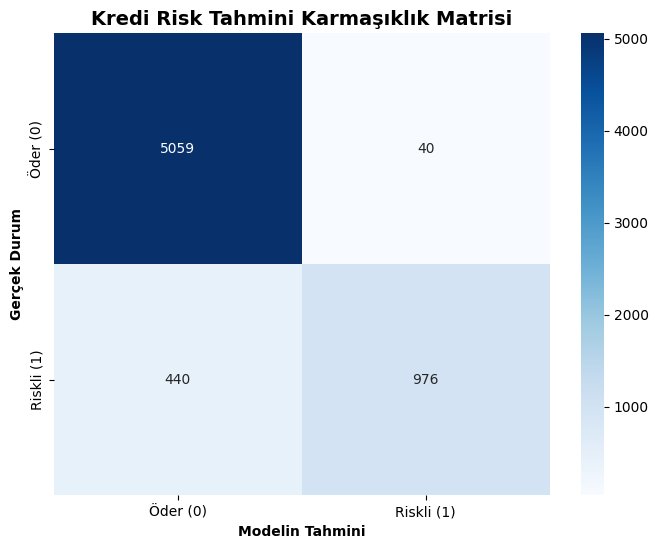


SİFİR AĞI DETAYLI SINAV RAPORU
              precision    recall  f1-score   support

    Öder (0)       0.92      0.99      0.95      5099
  Riskli (1)       0.96      0.69      0.80      1416

    accuracy                           0.93      6515
   macro avg       0.94      0.84      0.88      6515
weighted avg       0.93      0.93      0.92      6515



In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Sınavı Yapıyoruz (Ağ, test verisini değerlendiriyor)
# Bize 0 ile 1 arasında olasılıklar döndürecek
y_pred_prob = model.predict(X_test_scaled)

# 2. Olasılıkları 0 ve 1'e Çevirme (Barajımız 0.5)
# Sonuçları listeye çeviriyoruz ki gerçek sonuçlarla rahatça kıyaslayabilelim
y_pred = (y_pred_prob > 0.5).astype(int)

# 3. Karmaşıklık Matrisini (Confusion Matrix) Hesaplama
cm = confusion_matrix(y_test, y_pred)

# 4. Görselleştirme (Şov Kısmı)
plt.figure(figsize=(8, 6))
# Mavi tonlarında, içindeki sayıları ('d' ile tam sayı formatında) gösteren şık bir ısı haritası
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Öder (0)', 'Riskli (1)'], 
            yticklabels=['Öder (0)', 'Riskli (1)'])
plt.ylabel('Gerçek Durum', fontweight='bold')
plt.xlabel('Modelin Tahmini', fontweight='bold')
plt.title('Kredi Risk Tahmini Karmaşıklık Matrisi', fontsize=14, fontweight='bold')
plt.show()

# 5. Detaylı Başarı Raporu (Precision, Recall, F1-Score)
print("\n" + "="*50)
print("SİFİR AĞI DETAYLI SINAV RAPORU")
print("="*50)
print(classification_report(y_test, y_pred, target_names=['Öder (0)', 'Riskli (1)']))